## Loan & Financial Analysis

## Introduction

 - This project analyzes a loan portfolio of 9578 loan records to understand borrower financial characteristics, loan pricing, repayment behavior, credit risk and financial performance.
 - The analysis combines real-world loan portfolio data with financial mathematics and scenario modeling to demonstrate how data can support financial and business decision-making.

### Goal: 
 - To analyze loan portfolio data and apply financial mathematics to understand loan pricing, borrower financial health, repayment risk, financing costs, investment returns and financial decision-making.

In [5]:
# Install required libraries
%pip install pandas numpy matplotlib seaborn openpyxl numpy-financial

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy_financial as npf

In [3]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
print("All libraries imported successfully!")

All libraries imported successfully!


#### Phase 1 - Dataset Overview
 - Analyze the structure and quality of the loan dataset.

In [10]:
# Load Dataset
df = pd.read_csv("Downloads/loan_data.csv")

In [12]:
# Number of Rows and Columns
rows = df.shape[0]
columns = df.shape[1]
print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 9578
Number of Columns: 14


In [14]:
# Data Types
print("\nData Types:")
print(df.dtypes)


Data Types:
credit.policy          int64
purpose               object
int.rate             float64
installment          float64
log.annual.inc       float64
dti                  float64
fico                   int64
days.with.cr.line    float64
revol.bal              int64
revol.util           float64
inq.last.6mths         int64
delinq.2yrs            int64
pub.rec                int64
not.fully.paid         int64
dtype: object


In [16]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64


In [18]:
# Duplicate Records
duplicates = df.duplicated().sum()
print("\nDuplicate Records:", duplicates)


Duplicate Records: 0


In [20]:
# Unique Loan Purposes
unique_purposes = df["purpose"].unique()
print("\nUnique Loan Purposes:")
print(unique_purposes)
print("\nNumber of Unique Loan Purposes:",
      df["purpose"].nunique())


Unique Loan Purposes:
['debt_consolidation' 'credit_card' 'all_other' 'home_improvement'
 'small_business' 'major_purchase' 'educational']

Number of Unique Loan Purposes: 7


In [22]:
# Numerical Variables
numerical_variables = df.select_dtypes(
    include=np.number
).columns
print("\nNumerical Variables:")
print(list(numerical_variables))


Numerical Variables:
['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']


In [24]:
# Categorical Variables
categorical_variables = df.select_dtypes(
    exclude=np.number
).columns
print("\nCategorical Variables:")
print(list(categorical_variables))


Categorical Variables:
['purpose']


In [26]:
# Variable Classification: Classify variables based on their business meaning.
numerical_variables = [
    "int.rate",
    "installment",
    "log.annual.inc",
    "dti",
    "fico",
    "days.with.cr.line",
    "revol.bal",
    "revol.util",
    "inq.last.6mths",
    "delinq.2yrs",
    "pub.rec"]
categorical_variables = ["purpose"]
binary_variables = [
    "credit.policy",
    "not.fully.paid"]
print("Numerical Variables:")
print(numerical_variables)
print("\nCategorical Variables:")
print(categorical_variables)
print("\nBinary Variables:")
print(binary_variables)
print("\nNumber of Numerical Variables:",
      len(numerical_variables))
print("Number of Categorical Variables:",
      len(categorical_variables))
print("Number of Binary Variables:",
      len(binary_variables))

Numerical Variables:
['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

Categorical Variables:
['purpose']

Binary Variables:
['credit.policy', 'not.fully.paid']

Number of Numerical Variables: 11
Number of Categorical Variables: 1
Number of Binary Variables: 2


In [28]:
# Basic Data Dictionary: Create a business-friendly description of each variable.
data_dictionary = pd.DataFrame({
    "Variable": [
        "credit.policy",
        "purpose",
        "int.rate",
        "installment",
        "log.annual.inc",
        "dti",
        "fico",
        "days.with.cr.line",
        "revol.bal",
        "revol.util",
        "inq.last.6mths",
        "delinq.2yrs",
        "pub.rec",
        "not.fully.paid"],
    "Description": [
        "Indicates whether the borrower meets the lender's credit policy",
        "Purpose of the loan",
        "Interest rate charged on the loan",
        "Monthly loan installment",
        "Log-transformed annual income",
        "Debt-to-income ratio",
        "FICO credit score",
        "Number of days the borrower has had a credit line",
        "Revolving credit balance",
        "Revolving credit utilization percentage",
        "Number of credit inquiries in the last 6 months",
        "Number of delinquency events in the last 2 years",
        "Number of derogatory public records",
        "Indicates whether the loan was not fully paid"],
    "Business Category": [
        "Binary",
        "Categorical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Binary"]})
print(data_dictionary)

             Variable                                        Description  \
0       credit.policy  Indicates whether the borrower meets the lende...   
1             purpose                                Purpose of the loan   
2            int.rate                  Interest rate charged on the loan   
3         installment                           Monthly loan installment   
4      log.annual.inc                      Log-transformed annual income   
5                 dti                               Debt-to-income ratio   
6                fico                                  FICO credit score   
7   days.with.cr.line  Number of days the borrower has had a credit line   
8           revol.bal                           Revolving credit balance   
9          revol.util            Revolving credit utilization percentage   
10     inq.last.6mths    Number of credit inquiries in the last 6 months   
11        delinq.2yrs   Number of delinquency events in the last 2 years   
12          

#### Phase 1 insight
The dataset is clean from a missing-value and duplicate perspective, so we can move directly into portfolio analysis without needing major data-cleaning operations.

#### Phase 2 — Loan Portfolio Overview

In [33]:
# What are the most common loan purposes?
# Number of loans by purpose
loan_purpose_count = df["purpose"].value_counts()
# Percentage of total loans
loan_purpose_percentage = (
    df["purpose"].value_counts(normalize=True) * 100)
# Create summary table
purpose_summary = pd.DataFrame({
    "Loan Count": loan_purpose_count,
    "Percentage": loan_purpose_percentage})
purpose_summary["Percentage"] = (
    purpose_summary["Percentage"].round(2))
print("Loan Purpose Summary:")
print(purpose_summary)
# Most common loan purpose
most_common_purpose = loan_purpose_count.idxmax()
most_common_count = loan_purpose_count.max()
print("\nMost Common Loan Purpose:",
      most_common_purpose)
print("Number of Loans:",
      most_common_count)

Loan Purpose Summary:
                    Loan Count  Percentage
purpose                                   
debt_consolidation        3957       41.31
all_other                 2331       24.34
credit_card               1262       13.18
home_improvement           629        6.57
small_business             619        6.46
major_purchase             437        4.56
educational                343        3.58

Most Common Loan Purpose: debt_consolidation
Number of Loans: 3957


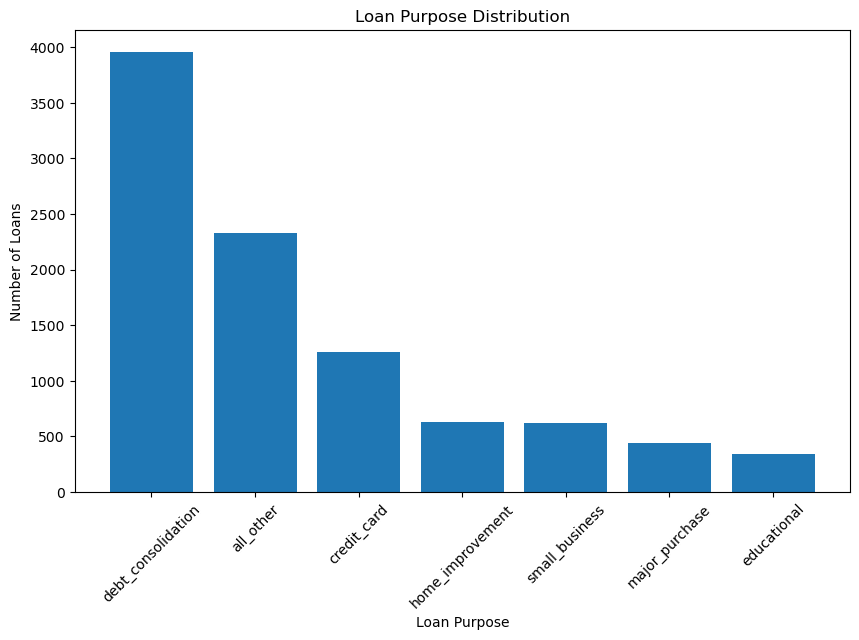

In [35]:
# Loan Purpose Distribution
plt.figure(figsize=(10, 6))
plt.bar(
    loan_purpose_count.index,
    loan_purpose_count.values)
plt.title("Loan Purpose Distribution")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45)
plt.show()

In [37]:
# Interest Rate Analysis
# Average Interest Rate
average_interest = df["int.rate"].mean()
# Median Interest Rate
median_interest = df["int.rate"].median()
# Minimum Interest Rate
minimum_interest = df["int.rate"].min()
# Maximum Interest Rate
maximum_interest = df["int.rate"].max()
print("Average Interest Rate:", round(average_interest * 100, 2), "%")
print("Median Interest Rate:", round(median_interest * 100, 2), "%")
print("Minimum Interest Rate:", round(minimum_interest * 100, 2), "%")
print("Maximum Interest Rate:", round(maximum_interest * 100, 2), "%")
# Average Interest Rate by Loan Purpose
purpose_interest = (
    df.groupby("purpose")["int.rate"]
    .mean()
    .sort_values(ascending=False))
purpose_interest = purpose_interest * 100
print("\nAverage Interest Rate by Loan Purpose:")
print(purpose_interest.round(2))

Average Interest Rate: 12.26 %
Median Interest Rate: 12.21 %
Minimum Interest Rate: 6.0 %
Maximum Interest Rate: 21.64 %

Average Interest Rate by Loan Purpose:
purpose
small_business       13.81
debt_consolidation   12.66
educational          11.99
credit_card          11.97
home_improvement     11.75
all_other            11.68
major_purchase       11.42
Name: int.rate, dtype: float64


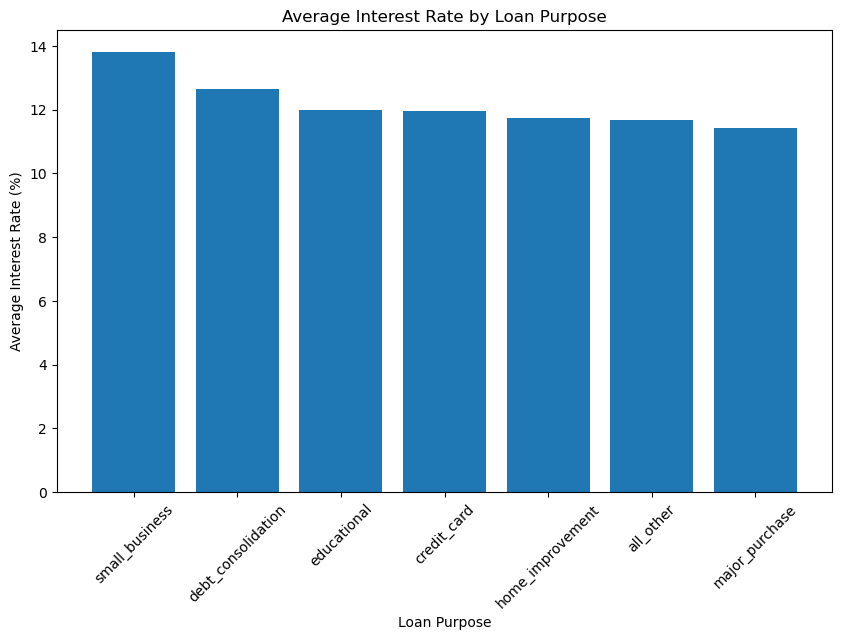

In [39]:
# Average Interest Rate by Loan Purpose
plt.figure(figsize=(10, 6))
plt.bar(
    purpose_interest.index,
    purpose_interest.values)
plt.title("Average Interest Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Average Interest Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [41]:
# Repayment Performance
# Count repayment outcomes
repayment_count = df["not.fully.paid"].value_counts()
# Number of fully paid loans
fully_paid = repayment_count[0]
# Number of not fully paid loans
not_fully_paid = repayment_count[1]
# Total loans
total_loans = len(df)
# Percentages
fully_paid_percentage = (fully_paid / total_loans) * 100
not_fully_paid_percentage = (not_fully_paid / total_loans) * 100
# Display results
print("Total Loans:", total_loans)
print("\nFully Paid Loans:", fully_paid)
print("Fully Paid Percentage:",
      round(fully_paid_percentage, 2), "%")
print("\nNot Fully Paid Loans:", not_fully_paid)
print("Not Fully Paid Percentage:",
      round(not_fully_paid_percentage, 2), "%")

Total Loans: 9578

Fully Paid Loans: 8045
Fully Paid Percentage: 83.99 %

Not Fully Paid Loans: 1533
Not Fully Paid Percentage: 16.01 %


In [43]:
# Installment Analysis
# Average Installment
average_installment = df["installment"].mean()
# Median Installment
median_installment = df["installment"].median()
# Minimum Installment
minimum_installment = df["installment"].min()
# Maximum Installment
maximum_installment = df["installment"].max()
print("Average Installment: ₹", round(average_installment, 2))
print("Median Installment: ₹", round(median_installment, 2))
print("Minimum Installment: ₹", round(minimum_installment, 2))
print("Maximum Installment: ₹", round(maximum_installment, 2))
# Average Installment by Loan Purpose
purpose_installment = (
    df.groupby("purpose")["installment"]
    .mean()
    .sort_values(ascending=False))
print("\nAverage Installment by Loan Purpose:")
print(purpose_installment.round(2))

Average Installment: ₹ 319.09
Median Installment: ₹ 268.95
Minimum Installment: ₹ 15.67
Maximum Installment: ₹ 940.14

Average Installment by Loan Purpose:
purpose
small_business       433.83
debt_consolidation   358.98
home_improvement     337.07
credit_card          319.50
all_other            244.94
major_purchase       243.48
educational          217.55
Name: installment, dtype: float64


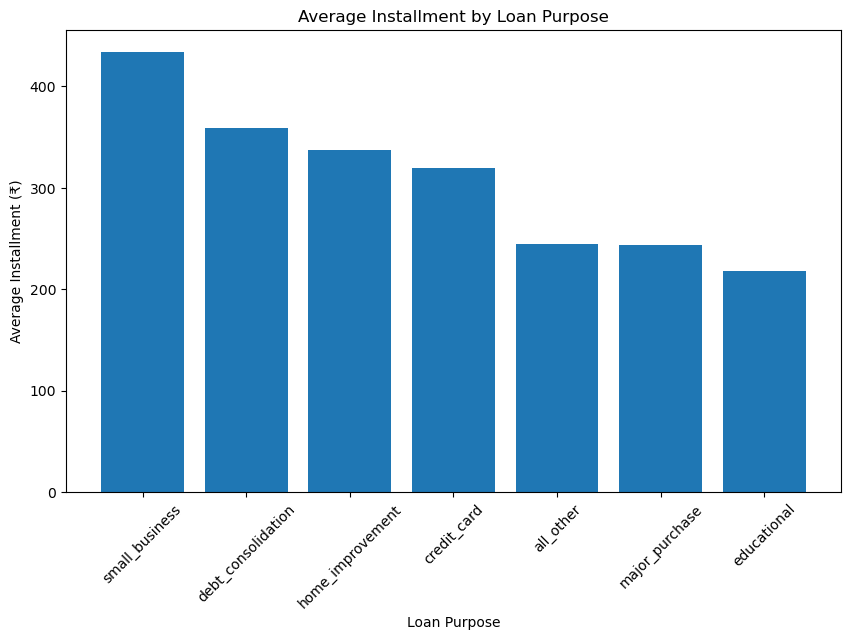

In [45]:
# Installment Analysis: Visualization
plt.figure(figsize=(10, 6))
plt.bar(
    purpose_installment.index,
    purpose_installment.values)
plt.title("Average Installment by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Average Installment (₹)")
plt.xticks(rotation=45)
plt.show()

#### Phase 2 — Business Insight
Debt consolidation is the largest loan segment, representing 41.31% of the portfolio. Small-business loans have the highest average interest rate (13.81%) and the highest average installment (₹433.83), indicating a relatively higher pricing and payment burden. Overall, 83.99% of loans were fully paid, while 16.01% were not fully paid.

This suggests that the portfolio is generally performing well, but differences in loan pricing and payment burden across purposes should be examined further to understand their relationship with borrower risk and repayment behavior.

#### Phase 3 — Borrower Financial Analysis

In [48]:
# Income Analysis
# Average income indicator by loan purpose
income_by_purpose = (
    df.groupby("purpose")["log.annual.inc"]
    .mean()
    .sort_values(ascending=False))
print("Average Log Annual Income by Loan Purpose:")
print(income_by_purpose.round(2))
# Average income indicator by repayment status
income_by_repayment = (
    df.groupby("not.fully.paid")["log.annual.inc"]
    .mean())
print("\nAverage Log Annual Income by Repayment Status:")
print(
    income_by_repayment.rename({
        0: "Fully Paid",
        1: "Not Fully Paid"
    }).round(2))

Average Log Annual Income by Loan Purpose:
purpose
home_improvement     11.20
small_business       11.15
credit_card          11.05
debt_consolidation   10.91
all_other            10.85
major_purchase       10.84
educational          10.55
Name: log.annual.inc, dtype: float64

Average Log Annual Income by Repayment Status:
not.fully.paid
Fully Paid       10.94
Not Fully Paid   10.89
Name: log.annual.inc, dtype: float64


In [51]:
# Debt-to-Income Ratio: DTI Analysis
# Overall DTI statistics
average_dti = df["dti"].mean()
median_dti = df["dti"].median()
minimum_dti = df["dti"].min()
maximum_dti = df["dti"].max()
print("Average DTI:", round(average_dti, 2))
print("Median DTI:", round(median_dti, 2))
print("Minimum DTI:", round(minimum_dti, 2))
print("Maximum DTI:", round(maximum_dti, 2))
# DTI by repayment status
dti_by_repayment = (
    df.groupby("not.fully.paid")["dti"]
    .mean())
dti_by_repayment.index = [
    "Fully Paid",
    "Not Fully Paid"]
print("\nAverage DTI by Repayment Status:")
print(dti_by_repayment.round(2))

Average DTI: 12.61
Median DTI: 12.66
Minimum DTI: 0.0
Maximum DTI: 29.96

Average DTI by Repayment Status:
Fully Paid       12.49
Not Fully Paid   13.20
Name: dti, dtype: float64


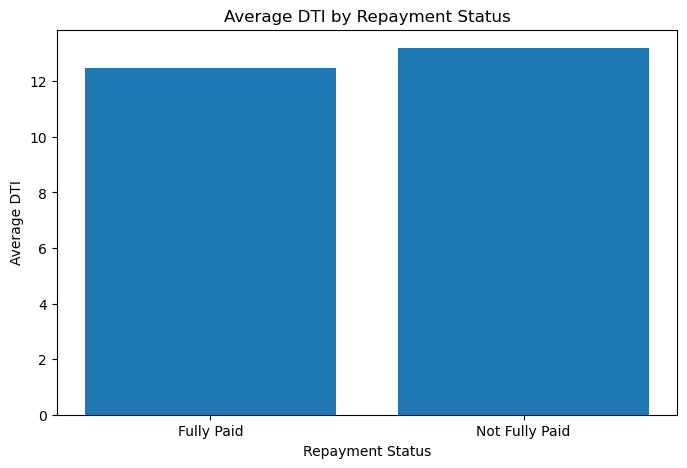

In [55]:
# Average DTI by Repayment Status - Visualization
plt.figure(figsize=(8, 5))
plt.bar(
    dti_by_repayment.index,
    dti_by_repayment.values)
plt.title("Average DTI by Repayment Status")
plt.xlabel("Repayment Status")
plt.ylabel("Average DTI")
plt.show()

In [57]:
# Fair Isaac Corporation Score - FICO Credit Score Analysis
# Overall FICO statistics
average_fico = df["fico"].mean()
median_fico = df["fico"].median()
minimum_fico = df["fico"].min()
maximum_fico = df["fico"].max()
print("Average FICO:", round(average_fico, 2))
print("Median FICO:", round(median_fico, 2))
print("Minimum FICO:", minimum_fico)
print("Maximum FICO:", maximum_fico)
# FICO by repayment status
fico_by_repayment = (
    df.groupby("not.fully.paid")["fico"]
    .mean()
    .rename({
        0: "Fully Paid",
        1: "Not Fully Paid"}))
print("\nAverage FICO by Repayment Status:")
print(fico_by_repayment.round(2))

Average FICO: 710.85
Median FICO: 707.0
Minimum FICO: 612
Maximum FICO: 827

Average FICO by Repayment Status:
not.fully.paid
Fully Paid       713.33
Not Fully Paid   697.83
Name: fico, dtype: float64


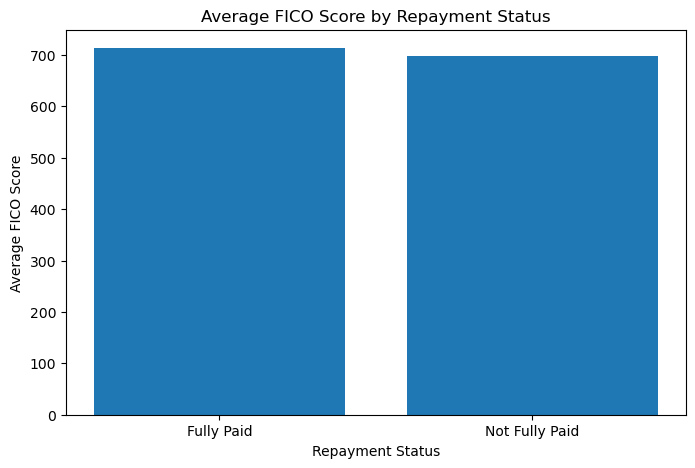

In [59]:
# Average FICO by Repayment Status - Visualisation
plt.figure(figsize=(8, 5))
plt.bar(
    fico_by_repayment.index,
    fico_by_repayment.values)
plt.title("Average FICO Score by Repayment Status")
plt.xlabel("Repayment Status")
plt.ylabel("Average FICO Score")
plt.show()

In [63]:
# Credit Risk Indicators
risk_indicators = [
    "inq.last.6mths",
    "delinq.2yrs",
    "pub.rec"]
# Average risk indicators by repayment status
risk_by_repayment = (
    df.groupby("not.fully.paid")[risk_indicators]
    .mean()
    .rename(index={
        0: "Fully Paid",
        1: "Not Fully Paid"}))
print("Average Credit Risk Indicators by Repayment Status:")
print(risk_by_repayment.round(2))

Average Credit Risk Indicators by Repayment Status:
                inq.last.6mths  delinq.2yrs  pub.rec
not.fully.paid                                      
Fully Paid                1.43         0.16     0.06
Not Fully Paid            2.33         0.17     0.09


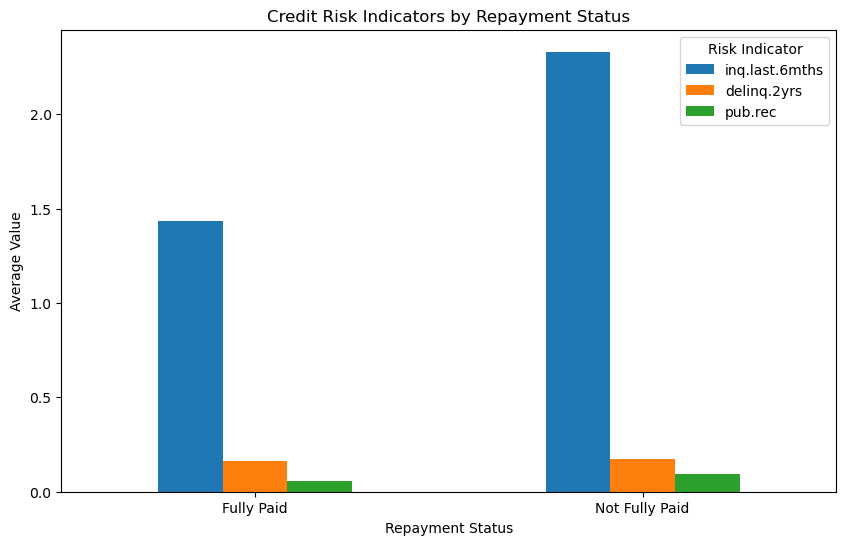

In [65]:
# Credit Risk Indicators by Repayment Status - Visualisation
risk_by_repayment.plot(
    kind="bar",
    figsize=(10, 6))
plt.title("Credit Risk Indicators by Repayment Status")
plt.xlabel("Repayment Status")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Risk Indicator")
plt.show()

#### Phase 3 — Business Insight
Borrower financial strength appears to be associated with repayment performance. Fully paid borrowers had slightly higher average income (10.94 vs 10.89) and lower DTI (12.49 vs 13.20), while their average FICO score was notably higher (713.33 vs 697.83). Not-fully-paid borrowers also had more recent credit inquiries (2.33 vs 1.43).

Overall, FICO and recent credit inquiries show stronger differences between repayment groups, while income and DTI show more modest differences. These indicators can therefore help identify borrower segments that may require closer credit-risk assessment.

#### Phase 4 — Loan Pricing & Repayment Analysis

In [69]:
# Interest Rate vs Installment
correlation = df["int.rate"].corr(df["installment"])
print("Correlation between Interest Rate and Installment:",
      round(correlation, 3))

Correlation between Interest Rate and Installment: 0.276


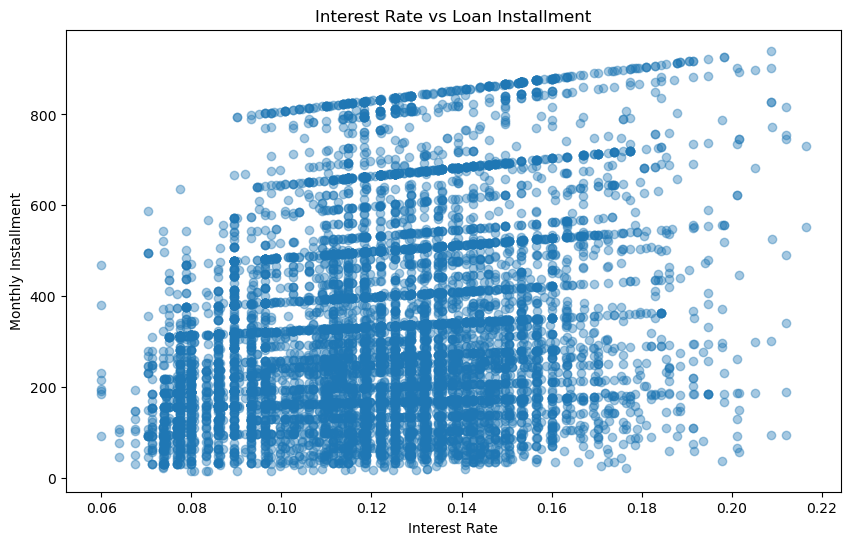

In [71]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["int.rate"],
    df["installment"],
    alpha=0.4)
plt.title("Interest Rate vs Loan Installment")
plt.xlabel("Interest Rate")
plt.ylabel("Monthly Installment")
plt.show()

In [73]:
# Interest Rate & Repayment Risk
# Create interest-rate bands
df["interest_band"] = pd.cut(
    df["int.rate"],
    bins=[0, 0.10, 0.15, float("inf")],
    labels=["Low Interest", "Medium Interest", "High Interest"])
# Calculate repayment performance by interest band
interest_risk = (
    df.groupby("interest_band", observed=True)["not.fully.paid"]
    .agg(["count", "sum", "mean"]))
interest_risk["not_fully_paid_percentage"] = interest_risk["mean"] * 100
print("Repayment Risk by Interest Rate Band:")
print(
    interest_risk[
        ["count", "sum", "not_fully_paid_percentage"]
    ].round(2))

Repayment Risk by Interest Rate Band:
                 count   sum  not_fully_paid_percentage
interest_band                                          
Low Interest      2185   162                       7.41
Medium Interest   5979  1021                      17.08
High Interest     1414   350                      24.75


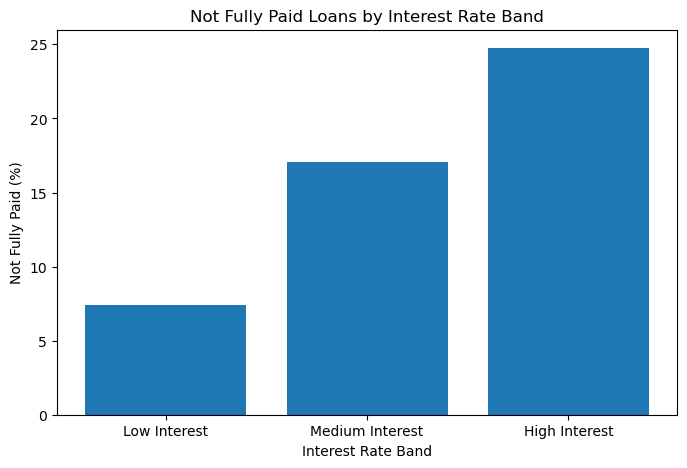

In [80]:
# Not Fully Paid % by Interest Rate Band
plt.figure(figsize=(8, 5))
plt.bar(
    interest_risk.index.astype(str),
    interest_risk["not_fully_paid_percentage"])
plt.title("Not Fully Paid Loans by Interest Rate Band")
plt.xlabel("Interest Rate Band")
plt.ylabel("Not Fully Paid (%)")
plt.show()

#### Phase 4 - Insight
Loan pricing and repayment outcomes show a clear relationship with risk. Small-business loans have the highest average interest rate and installment, while higher-interest loans show substantially higher repayment risk: 24.75% of high-interest loans were not fully paid compared with only 7.41% of low-interest loans. Interest rate and installment have a weak positive correlation (0.276), suggesting that interest rate alone does not determine payment burden.

Overall, higher-priced loans appear to be associated with greater repayment difficulty, highlighting the importance of considering borrower credit quality and financial capacity alongside loan pricing.

#### Phase 5 — Financial Mathematics & Scenario Modeling

In [83]:
# Compound Interest & Future Value
principal = 500000
time = 5
rates = [0.08, 0.10, 0.12]
for rate in rates:
# Future Value
    future_value = principal * (1 + rate) ** time
# Compound Interest
    compound_interest = future_value - principal
    print("Annual Return:", rate * 100, "%")
    print("Future Value: ₹", round(future_value, 2))
    print("Compound Interest: ₹", round(compound_interest, 2))
    print("-" * 40)

Annual Return: 8.0 %
Future Value: ₹ 734664.04
Compound Interest: ₹ 234664.04
----------------------------------------
Annual Return: 10.0 %
Future Value: ₹ 805255.0
Compound Interest: ₹ 305255.0
----------------------------------------
Annual Return: 12.0 %
Future Value: ₹ 881170.84
Compound Interest: ₹ 381170.84
----------------------------------------


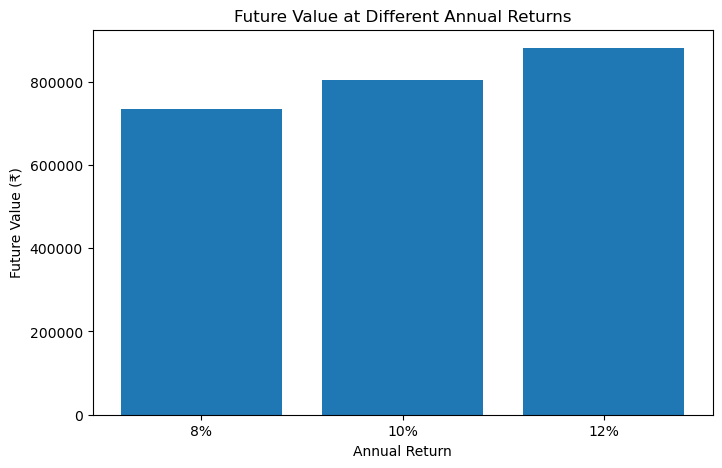

In [85]:
# Future Value Comparison
future_values = []
for rate in rates:
    future_value = principal * (1 + rate) ** time
    future_values.append(future_value)
plt.figure(figsize=(8, 5))
plt.bar(
    ["8%", "10%", "12%"],
    future_values)
plt.title("Future Value at Different Annual Returns")
plt.xlabel("Annual Return")
plt.ylabel("Future Value (₹)")
plt.show()

In [87]:
# Present Value & Discounting
future_value = 1000000
time = 5
discount_rates = [0.08, 0.10, 0.12]
for rate in discount_rates:
# Present Value
    present_value = future_value / (1 + rate) ** time
    print("Discount Rate:", rate * 100, "%")
    print("Present Value: ₹", round(present_value, 2))
    print("-" * 40)

Discount Rate: 8.0 %
Present Value: ₹ 680583.2
----------------------------------------
Discount Rate: 10.0 %
Present Value: ₹ 620921.32
----------------------------------------
Discount Rate: 12.0 %
Present Value: ₹ 567426.86
----------------------------------------


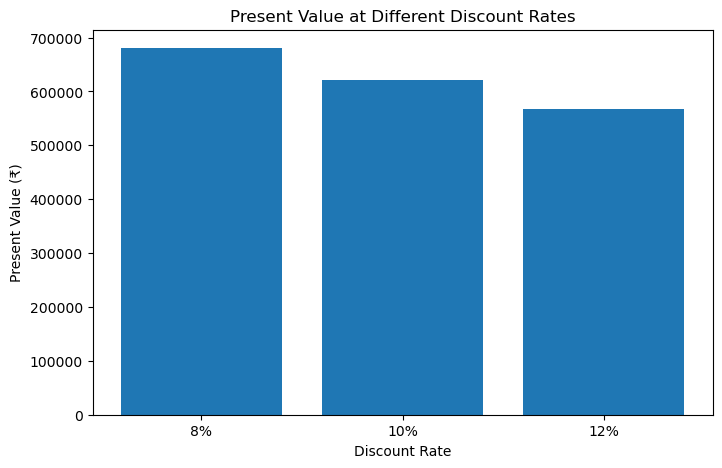

In [89]:
# Present Value at Different Discount Rates
present_values = []
for rate in discount_rates:
    present_value = future_value / (1 + rate) ** time
    present_values.append(present_value)
plt.figure(figsize=(8, 5))
plt.bar(
    ["8%", "10%", "12%"],
    present_values)
plt.title("Present Value at Different Discount Rates")
plt.xlabel("Discount Rate")
plt.ylabel("Present Value (₹)")
plt.show()

In [91]:
# Inflation-Adjusted Value
current_value = 1000000
inflation_rate = 0.06
time = 8
# Inflation-adjusted purchasing power
future_purchasing_power = current_value / (1 + inflation_rate) ** time
print("Current Value: ₹", current_value)
print("Inflation Rate:", inflation_rate * 100, "%")
print("Time:", time, "years")
print("Purchasing-Power Value After 8 Years: ₹",
      round(future_purchasing_power, 2))

Current Value: ₹ 1000000
Inflation Rate: 6.0 %
Time: 8 years
Purchasing-Power Value After 8 Years: ₹ 627412.37


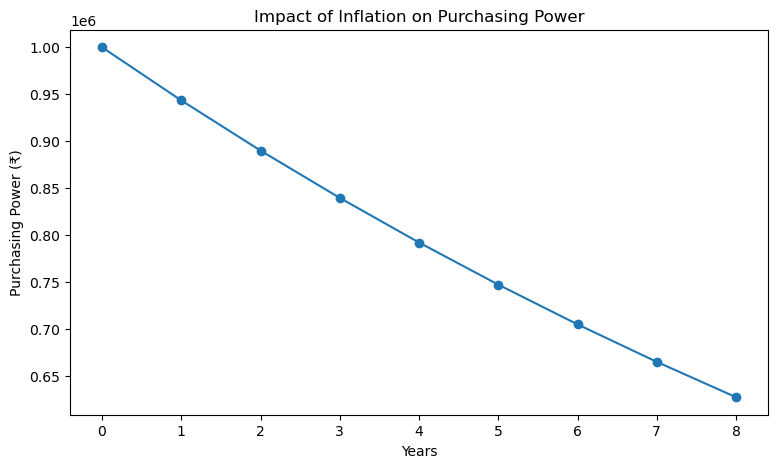

In [93]:
# Purchasing Power Over Time
years = list(range(0, 9))
purchasing_power = []
for year in years:
    value = current_value / (1 + inflation_rate) ** year
    purchasing_power.append(value)
plt.figure(figsize=(9, 5))
plt.plot(years, purchasing_power, marker="o")
plt.title("Impact of Inflation on Purchasing Power")
plt.xlabel("Years")
plt.ylabel("Purchasing Power (₹)")
plt.show()

In [95]:
# CAGR Comparison
investments = {
    "Investment A": [500000, 800000, 5],
    "Investment B": [1000000, 1800000, 6],
    "Investment C": [800000, 1500000, 7]}
cagr_results = {}
for name, values in investments.items():
    initial_value = values[0]
    final_value = values[1]
    years = values[2]
# CAGR
    cagr = (final_value / initial_value) ** (1 / years) - 1
    cagr_results[name] = cagr * 100
    print(name)
    print("CAGR:", round(cagr * 100, 2), "%")
    print("-" * 40)
# Find highest CAGR
highest_cagr = max(cagr_results, key=cagr_results.get)
print("Highest CAGR:", highest_cagr)

Investment A
CAGR: 9.86 %
----------------------------------------
Investment B
CAGR: 10.29 %
----------------------------------------
Investment C
CAGR: 9.4 %
----------------------------------------
Highest CAGR: Investment B


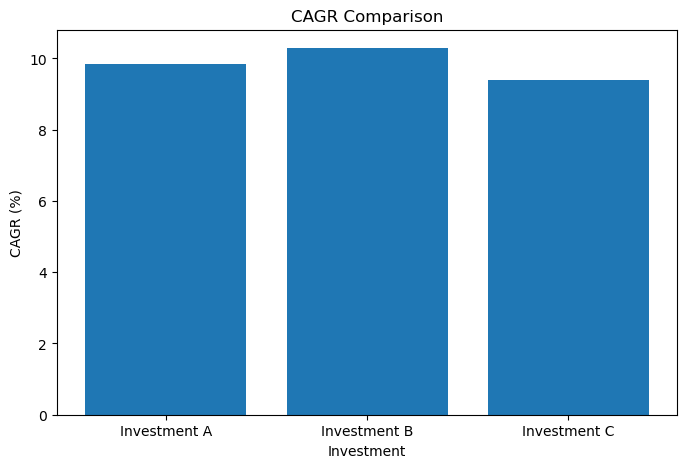

In [99]:
# CAGR Comparison
plt.figure(figsize=(8, 5))
plt.bar(
    cagr_results.keys(),
    cagr_results.values())
plt.title("CAGR Comparison")
plt.xlabel("Investment")
plt.ylabel("CAGR (%)")
plt.show()

In [101]:
# Loan Comparison
principal = 1000000
# Loan A
rate_a = 0.09
years_a = 5
monthly_rate_a = rate_a / 12
months_a = years_a * 12
emi_a = npf.pmt(monthly_rate_a, months_a, -principal)
total_payment_a = emi_a * months_a
total_interest_a = total_payment_a - principal
# Loan B
rate_b = 0.08
years_b = 7
monthly_rate_b = rate_b / 12
months_b = years_b * 12
emi_b = npf.pmt(monthly_rate_b, months_b, -principal)
total_payment_b = emi_b * months_b
total_interest_b = total_payment_b - principal
# Display results
print("LOAN A")
print("Monthly EMI: ₹", round(emi_a, 2))
print("Total Repayment: ₹", round(total_payment_a, 2))
print("Total Interest: ₹", round(total_interest_a, 2))
print("\nLOAN B")
print("Monthly EMI: ₹", round(emi_b, 2))
print("Total Repayment: ₹", round(total_payment_b, 2))
print("Total Interest: ₹", round(total_interest_b, 2))

LOAN A
Monthly EMI: ₹ 20758.36
Total Repayment: ₹ 1245501.31
Total Interest: ₹ 245501.31

LOAN B
Monthly EMI: ₹ 15586.21
Total Repayment: ₹ 1309242.01
Total Interest: ₹ 309242.01


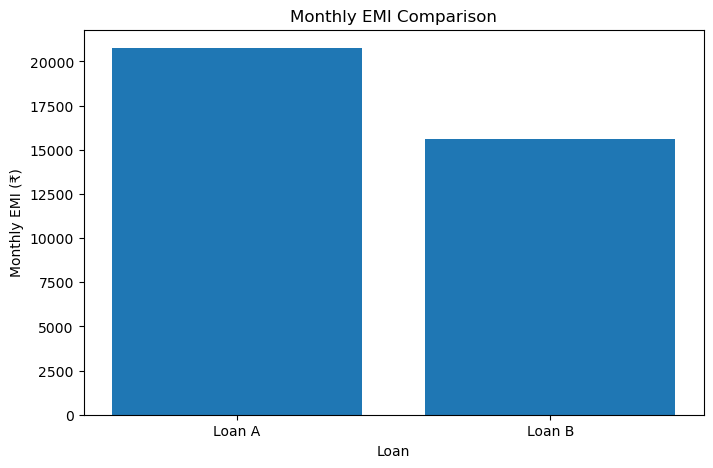

In [103]:
# EMI Comparison
loan_names = ["Loan A", "Loan B"]
emi_values = [emi_a, emi_b]
plt.figure(figsize=(8, 5))
plt.bar(loan_names, emi_values)
plt.title("Monthly EMI Comparison")
plt.xlabel("Loan")
plt.ylabel("Monthly EMI (₹)")
plt.show()

In [105]:
# Loan Amortization Schedule
principal = 1000000
annual_rate = 0.09
years = 5
monthly_rate = annual_rate / 12
total_months = years * 12
# Monthly EMI
emi = npf.pmt(monthly_rate, total_months, -principal)
opening_balance = principal
amortization = []
for month in range(1, total_months + 1):
# Interest for the month
    interest = opening_balance * monthly_rate
# Principal portion of EMI
    principal_paid = emi - interest
# Remaining loan balance
    closing_balance = opening_balance - principal_paid
    amortization.append([
        month,
        opening_balance,
        emi,
        interest,
        principal_paid,
        closing_balance])
    opening_balance = closing_balance
# Create DataFrame
amortization_df = pd.DataFrame(
    amortization,
    columns=[
        "Month",
        "Opening Balance",
        "EMI",
        "Interest",
        "Principal",
        "Closing Balance"])
amortization_df

,Month,Opening Balance,EMI,Interest,Principal,Closing Balance
0,1,"1,000,000.00","20,758.36","7,500.00","13,258.36","986,741.64"
1,2,"986,741.64","20,758.36","7,400.56","13,357.79","973,383.85"
2,3,"973,383.85","20,758.36","7,300.38","13,457.98","959,925.88"
3,4,"959,925.88","20,758.36","7,199.44","13,558.91","946,366.96"
4,5,"946,366.96","20,758.36","7,097.75","13,660.60","932,706.36"
5,6,"932,706.36","20,758.36","6,995.30","13,763.06","918,943.30"
6,7,"918,943.30","20,758.36","6,892.07","13,866.28","905,077.02"
7,8,"905,077.02","20,758.36","6,788.08","13,970.28","891,106.75"
8,9,"891,106.75","20,758.36","6,683.30","14,075.05","877,031.69"
9,10,"877,031.69","20,758.36","6,577.74","14,180.62","862,851.07"


In [107]:
# Total Interest
total_interest = amortization_df["Interest"].sum()
# Total Principal
total_principal = amortization_df["Principal"].sum()
# Year 1
year1 = amortization_df[amortization_df["Month"] <= 12]
year1_interest = year1["Interest"].sum()
year1_principal = year1["Principal"].sum()
# Outstanding balance after Year 3
balance_after_year3 = amortization_df.loc[
    amortization_df["Month"] == 36,
    "Closing Balance"
].iloc[0]
print("Total Interest: ₹", round(total_interest, 2))
print("Total Principal Repaid: ₹", round(total_principal, 2))
print("Year 1 Interest: ₹", round(year1_interest, 2))
print("Year 1 Principal: ₹", round(year1_principal, 2))
print("Outstanding Balance After Year 3: ₹", round(balance_after_year3, 2))

Total Interest: ₹ 245501.31
Total Principal Repaid: ₹ 1000000.0
Year 1 Interest: ₹ 83270.24
Year 1 Principal: ₹ 165830.02
Outstanding Balance After Year 3: ₹ 454382.67


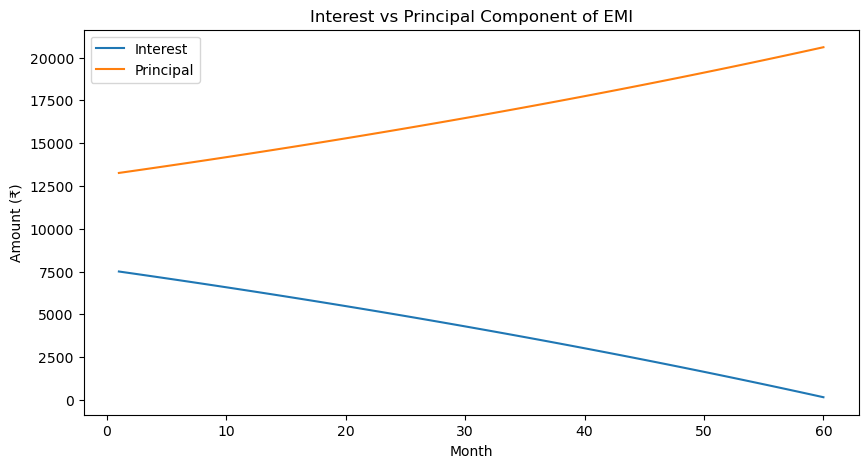

In [109]:
# Interest vs Principal Over Loan Period
plt.figure(figsize=(10, 5))
plt.plot(
    amortization_df["Month"],
    amortization_df["Interest"],
    label="Interest")
plt.plot(
    amortization_df["Month"],
    amortization_df["Principal"],
    label="Principal")
plt.title("Interest vs Principal Component of EMI")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.legend()
plt.show()

In [113]:
# Loan Comparison Summary
loan_comparison = pd.DataFrame({
    "Metric": [
        "Monthly EMI",
        "Total Repayment",
        "Total Interest"],
    "Loan A": [
        emi_a,
        total_payment_a,
        total_interest_a],
    "Loan B": [
        emi_b,
        total_payment_b,
        total_interest_b]})
loan_comparison

,Metric,Loan A,Loan B
0,Monthly EMI,"20,758.36","15,586.21"
1,Total Repayment,"1,245,501.31","1,309,242.01"
2,Total Interest,"245,501.31","309,242.01"


In [115]:
# Difference between Loan A and Loan B
emi_difference = emi_a - emi_b
interest_difference = total_interest_b - total_interest_a
print("Loan B saves monthly cash flow by: ₹", round(emi_difference, 2))
print("Loan A saves total interest by: ₹", round(interest_difference, 2))

Loan B saves monthly cash flow by: ₹ 5172.14
Loan A saves total interest by: ₹ 63740.7


#### Phase 6 — Business Insight
Loan A is financially cheaper overall, with a lower EMI of ₹20,758? Wait—Loan B actually has the lower EMI at ₹15,586, reducing monthly cash-flow pressure by about ₹5,172. However, Loan A has a lower total interest cost of ₹2.46 lakh, compared with ₹3.09 lakh for Loan B, saving approximately ₹63,741 over the loan term. The amortization analysis also shows that the interest component falls over time while the principal repayment increases. Therefore, Loan B is better for monthly affordability, while Loan A is better for minimizing total financing cost.

#### Phase 7 — Investment Evaluation

In [120]:
# ROI + Payback Period
initial_investment = 1000000
cash_flows = [200000, 250000, 300000, 350000, 400000]
# Total Cash Inflows
total_cash_inflows = sum(cash_flows)
# ROI
roi = (total_cash_inflows - initial_investment) / initial_investment * 100
# Payback Period
cumulative_cash_flow = 0
payback_period = 0
for cash_flow in cash_flows:
    previous_cumulative = cumulative_cash_flow
    cumulative_cash_flow += cash_flow
    if cumulative_cash_flow >= initial_investment:
        remaining_amount = initial_investment - previous_cumulative
        fraction_of_year = remaining_amount / cash_flow
        payback_period = (cash_flows.index(cash_flow) + 1) - 1 + fraction_of_year
        break
print("Total Cash Inflows: ₹", total_cash_inflows)
print("ROI:", round(roi, 2), "%")
print("Payback Period:", round(payback_period, 2), "years")

Total Cash Inflows: ₹ 1500000
ROI: 50.0 %
Payback Period: 3.71 years


In [122]:
# NPV
initial_investment = 1000000
cash_flows = [200000, 250000, 300000, 350000, 400000]
discount_rate = 0.10
# Calculate PV of each cash flow
present_values = []
for year, cash_flow in enumerate(cash_flows, start=1):
    pv = cash_flow / (1 + discount_rate) ** year
    present_values.append(pv)
    print("Year", year)
    print("Cash Flow: ₹", cash_flow)
    print("Present Value: ₹", round(pv, 2))
    print("-" * 40)
# Total PV
total_pv = sum(present_values)
# NPV
npv = total_pv - initial_investment
print("Total Present Value: ₹", round(total_pv, 2))
print("NPV: ₹", round(npv, 2))

Year 1
Cash Flow: ₹ 200000
Present Value: ₹ 181818.18
----------------------------------------
Year 2
Cash Flow: ₹ 250000
Present Value: ₹ 206611.57
----------------------------------------
Year 3
Cash Flow: ₹ 300000
Present Value: ₹ 225394.44
----------------------------------------
Year 4
Cash Flow: ₹ 350000
Present Value: ₹ 239054.71
----------------------------------------
Year 5
Cash Flow: ₹ 400000
Present Value: ₹ 248368.53
----------------------------------------
Total Present Value: ₹ 1101247.43
NPV: ₹ 101247.43


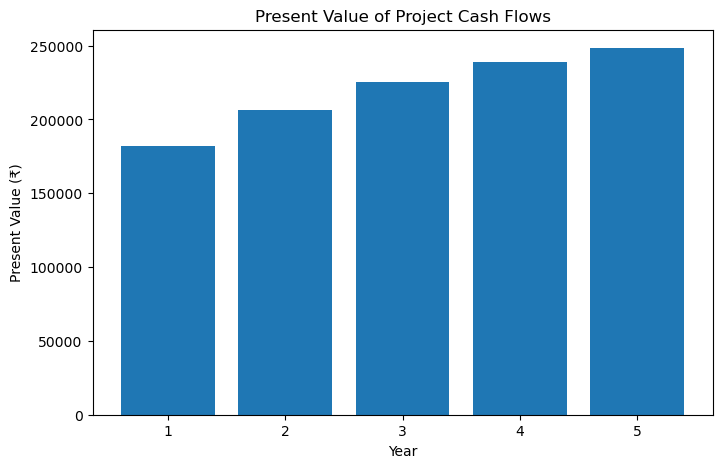

In [124]:
# PV of Cash Flows
years = [1, 2, 3, 4, 5]
plt.figure(figsize=(8, 5))
plt.bar(years, present_values)
plt.title("Present Value of Project Cash Flows")
plt.xlabel("Year")
plt.ylabel("Present Value (₹)")
plt.show()

In [126]:
# IRR
initial_investment = 1000000
cash_flows = [-initial_investment, 200000, 250000, 300000, 350000, 400000]
# Calculate IRR
irr = npf.irr(cash_flows)
print("IRR:", round(irr * 100, 2), "%")

IRR: 13.45 %


In [128]:
# Final Investment Decision
print("PROJECT EVALUATION")
print("-" * 40)
print("ROI:", round(roi, 2), "%")
print("Payback Period:", round(payback_period, 2), "years")
print("NPV: ₹", round(npv, 2))
print("IRR:", round(irr * 100, 2), "%")
print("Required Return:", discount_rate * 100, "%")
print("\nFINAL DECISION")
if npv > 0 and irr > discount_rate:
    print("ACCEPT — The project is financially attractive.")
else:
    print("REJECT — The project does not meet the required return.")

PROJECT EVALUATION
----------------------------------------
ROI: 50.0 %
Payback Period: 3.71 years
NPV: ₹ 101247.43
IRR: 13.45 %
Required Return: 10.0 %

FINAL DECISION
ACCEPT — The project is financially attractive.


#### Management Recommendation

The project should be accepted because it generates a positive NPV of 1,1,2 7
and an IRR of 13.45%, which is higher than the required return of 10%.

The project also generates a 50% ROI and recovers the initial investme t in
approximately 3.71 years. Overall, the project appears financially  iable
and creates value for the company.

#### Phase 7 — Investment Evaluation Conclusion

The hypothetical project appears financially attractive. It generates a 50% ROI, recovers the initial investment in approximately 3.71 years and produces a positive NPV of ₹1.01 lakh at the 10% required return. Its 13.45% IRR is also above the 10% hurdle rate, indicating that the project earns more than the minimum return expected by management. Therefore, based on ROI, Payback, NPV and IRR, the project should be accepted.

#### Phase 8 — Loan & Investment Comparison

In [134]:
# Loan & Investment Comparison
comparison = pd.DataFrame({
    "Metric": ["Interest / Return", "Monthly EMI", "Total Interest", "ROI", "NPV", "IRR", "Payback Period"],
    "Loan A": ["9%", emi_a, total_interest_a, np.nan, np.nan, np.nan, np.nan],
    "Loan B": ["8%", emi_b, total_interest_b, np.nan, np.nan, np.nan, np.nan],
    "Project": ["10% Required Return", np.nan, np.nan, roi, npv, irr * 100, payback_period]})
comparison

,Metric,Loan A,Loan B,Project
0,Interest / Return,9%,8%,10% Required Return
1,Monthly EMI,"20,758.36","15,586.21",NaN
2,Total Interest,"245,501.31","309,242.01",NaN
3,ROI,NaN,NaN,50.00
4,NPV,NaN,NaN,"101,247.43"
5,IRR,NaN,NaN,13.45
6,Payback Period,NaN,NaN,3.71


In [136]:
# Round numerical values for cleaner presentation
comparison.round(2)

,Metric,Loan A,Loan B,Project
0,Interest / Return,9%,8%,10% Required Return
1,Monthly EMI,"20,758.36","15,586.21",NaN
2,Total Interest,"245,501.31","309,242.01",NaN
3,ROI,NaN,NaN,50.00
4,NPV,NaN,NaN,"101,247.43"
5,IRR,NaN,NaN,13.45
6,Payback Period,NaN,NaN,3.71


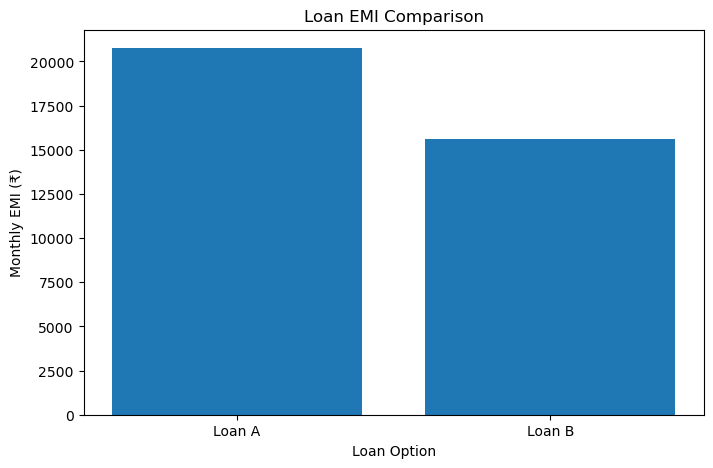

In [138]:
# Compare Loan EMI
plt.figure(figsize=(8, 5))
plt.bar(
    ["Loan A", "Loan B"],
    [emi_a, emi_b])
plt.title("Loan EMI Comparison")
plt.xlabel("Loan Option")
plt.ylabel("Monthly EMI (₹)")
plt.show()

#### Phase 8 — Loan & Investment Comparison: Conclusion

The comparison shows a clear trade-off between monthly affordability and total financing cost. Loan A has a higher EMI of ₹20758.36, but its total interest cost is lower at ₹245501.31. Loan B has a much lower EMI of ₹15586.21, making it easier on monthly cash flow, but the longer tenure increases total interest to ₹309242.01.

The hypothetical project is financially attractive, with a 50% ROI, positive NPV of ₹101247.43 and IRR of 13.45%, which exceeds the 10% required return. Its 3.71-year payback period also indicates that the initial investment is recovered within the project period.

#### Phase 9 — Risk & Financial

In [149]:
# FICO Risk Analysis
# Analyze repayment performance across FICO score bands.
# FICO Bands: Low FICO = below 650, Medium FICO = 650–699, High FICO = 700 and above
# Calculate:
# 1. Number of loans in each FICO band
# 2. Number of loans not fully paid
# 3. Percentage of loans not fully paid
df["fico_band"] = pd.cut(
    df["fico"],
    bins=[0, 649, 699, float("inf")],
    labels=["Low FICO", "Medium FICO", "High FICO"])
fico_risk = df.groupby("fico_band", observed=True).agg(
    total_loans=("fico", "count"),
    not_fully_paid=("not.fully.paid", "sum"))
# Calculate percentage not fully paid
fico_risk["not_fully_paid_rate"] = (
    fico_risk["not_fully_paid"] /
    fico_risk["total_loans"]
) * 100
fico_risk["not_fully_paid_rate"] = fico_risk["not_fully_paid_rate"].round(2)
fico_risk

,total_loans,not_fully_paid,not_fully_paid_rate
fico_band,,,
Low FICO,231,74,32.03
Medium FICO,3990,800,20.05
High FICO,5357,659,12.30


In [153]:
# DTI Risk Analysis
# Analyze repayment performance across DTI bands.
# DTI Bands: Low DTI = below 10, Medium DTI = 10–19.99, High DTI = 20 and above
# Calculate:
# 1. Number of loans in each DTI band
# 2. Number of loans not fully paid
# 3. Percentage of loans not fully paid
df["dti_band"] = pd.cut(
    df["dti"],
    bins=[-float("inf"), 9.99, 19.99, float("inf")],
    labels=["Low DTI", "Medium DTI", "High DTI"])
dti_risk = df.groupby("dti_band", observed=True).agg(
    total_loans=("dti", "count"),
    not_fully_paid=("not.fully.paid", "sum"))
# Calculate percentage not fully paid
dti_risk["not_fully_paid_rate"] = (
    dti_risk["not_fully_paid"] /
    dti_risk["total_loans"]) * 100
dti_risk["not_fully_paid_rate"] = dti_risk["not_fully_paid_rate"].round(2)
dti_risk

,total_loans,not_fully_paid,not_fully_paid_rate
dti_band,,,
Low DTI,3594,533,14.83
Medium DTI,4347,700,16.10
High DTI,1637,300,18.33


In [155]:
# Loan Purpose Risk Analysis
# Analyze repayment performance across different loan purposes.
# Calculate:
# 1. Number of loans for each purpose
# 2. Number of loans not fully paid
# 3. Percentage of loans not fully paid
purpose_risk = df.groupby("purpose").agg(
    total_loans=("purpose", "count"),
    not_fully_paid=("not.fully.paid", "sum"))
# Calculate percentage not fully paid
purpose_risk["not_fully_paid_rate"] = (
    purpose_risk["not_fully_paid"] /
    purpose_risk["total_loans"]
) * 100
purpose_risk["not_fully_paid_rate"] = (
    purpose_risk["not_fully_paid_rate"].round(2))
purpose_risk = purpose_risk.sort_values(
    "not_fully_paid_rate",
    ascending=False)
purpose_risk

,total_loans,not_fully_paid,not_fully_paid_rate
purpose,,,
small_business,619,172,27.79
educational,343,69,20.12
home_improvement,629,107,17.01
all_other,2331,387,16.60
debt_consolidation,3957,603,15.24
credit_card,1262,146,11.57
major_purchase,437,49,11.21


In [157]:
# Credit Inquiry Risk Analysis
# Analyze repayment performance based on recent credit inquiries.
# Calculate:
# 1. Number of loans in each credit-inquiry group
# 2. Number of loans not fully paid
# 3. Percentage of loans not fully paid
inquiry_risk = df.groupby("inq.last.6mths").agg(
    total_loans=("inq.last.6mths", "count"),
    not_fully_paid=("not.fully.paid", "sum"))
# Calculate percentage not fully paid
inquiry_risk["not_fully_paid_rate"] = (
    inquiry_risk["not_fully_paid"] /
    inquiry_risk["total_loans"]
) * 100
inquiry_risk["not_fully_paid_rate"] = (
    inquiry_risk["not_fully_paid_rate"].round(2))
inquiry_risk

,total_loans,not_fully_paid,not_fully_paid_rate
inq.last.6mths,,,
0,3637,427,11.74
1,2462,372,15.11
2,1384,198,14.31
3,864,180,20.83
4,475,112,23.58
5,278,76,27.34
6,165,54,32.73
7,100,37,37.00
8,72,29,40.28


In [159]:
# Delinquency Risk Analysis
# Analyze repayment performance based on previous delinquencies.
# Calculate:
# 1. Number of loans in each delinquency group
# 2. Number of loans not fully paid
# 3. Percentage of loans not fully paid
delinq_risk = df.groupby("delinq.2yrs").agg(
    total_loans=("delinq.2yrs", "count"),
    not_fully_paid=("not.fully.paid", "sum"))
# Calculate percentage not fully paid
delinq_risk["not_fully_paid_rate"] = (
    delinq_risk["not_fully_paid"] /
    delinq_risk["total_loans"]
) * 100
delinq_risk["not_fully_paid_rate"] = (
    delinq_risk["not_fully_paid_rate"].round(2))
delinq_risk

,total_loans,not_fully_paid,not_fully_paid_rate
delinq.2yrs,,,
0,8458,1337,15.81
1,832,145,17.43
2,192,34,17.71
3,65,13,20.00
4,19,4,21.05
5,6,0,0.00
6,2,0,0.00
7,1,0,0.00
8,1,0,0.00


In [161]:
# Insight 1
# Compare repayment risk across FICO bands.
highest_fico_risk = fico_risk["not_fully_paid_rate"].idxmax()
lowest_fico_risk = fico_risk["not_fully_paid_rate"].idxmin()
print(
    "Highest repayment risk:",
    highest_fico_risk,
    "with",
    fico_risk.loc[highest_fico_risk, "not_fully_paid_rate"],
    "%")
print(
    "Lowest repayment risk:",
    lowest_fico_risk,
    "with",
    fico_risk.loc[lowest_fico_risk, "not_fully_paid_rate"],
    "%")

Highest repayment risk: Low FICO with 32.03 %
Lowest repayment risk: High FICO with 12.3 %


##### Insight 1
Lower FICO borrowers show substantially higher repayment risk. Low-FICO loans have a 32.03% not-fully-paid rate compared with 12.30% for high-FICO loans, indicating a strong association between weaker credit quality and repayment risk.

In [163]:
# Insight 2
# Compare repayment risk across DTI bands.
highest_dti_risk = dti_risk["not_fully_paid_rate"].idxmax()
lowest_dti_risk = dti_risk["not_fully_paid_rate"].idxmin()
print(
    "Highest repayment risk:",
    highest_dti_risk,
    "with",
    dti_risk.loc[highest_dti_risk, "not_fully_paid_rate"],
    "%")
print(
    "Lowest repayment risk:",
    lowest_dti_risk,
    "with",
    dti_risk.loc[lowest_dti_risk, "not_fully_paid_rate"],
    "%")

Highest repayment risk: High DTI with 18.33 %
Lowest repayment risk: Low DTI with 14.83 %


##### Insight 2
Higher DTI is associated with higher repayment risk. High-DTI loans have an 18.33% not-fully-paid rate compared with 14.83% for low-DTI loans, suggesting that greater debt burden may be associated with weaker repayment performance.

In [167]:
# Insight 3
# Identify the loan purpose with the highest and lowest repayment risk.
highest_purpose_risk = purpose_risk["not_fully_paid_rate"].idxmax()
lowest_purpose_risk = purpose_risk["not_fully_paid_rate"].idxmin()
print(
    "Highest repayment risk:",
    highest_purpose_risk,
    "with",
    purpose_risk.loc[highest_purpose_risk, "not_fully_paid_rate"],
    "%")
print(
    "Lowest repayment risk:",
    lowest_purpose_risk,
    "with",
    purpose_risk.loc[lowest_purpose_risk, "not_fully_paid_rate"],
    "%")

Highest repayment risk: small_business with 27.79 %
Lowest repayment risk: major_purchase with 11.21 %


#### Insight 3
Loan purpose is associated with different levels of repayment risk. Small-business loans have the highest not-fully-paid rate at 27.79%, while major-purchase loans have the lowest at 11.21%. This suggests that loan purpose should be considered when assessing repayment risk.

In [170]:
# Insight 4
# Compare repayment risk between borrowers with no recent credit inquiries and borrowers with multiple recent inquiries.
low_inquiry_rate = inquiry_risk.loc[0, "not_fully_paid_rate"]
# Consider borrowers with 5 or more inquiries
high_inquiry_risk = inquiry_risk.loc[
    inquiry_risk.index >= 5,
    "not_fully_paid_rate"
].max()
high_inquiry_count = inquiry_risk.loc[
    inquiry_risk.index >= 5,
    "not_fully_paid_rate"
].idxmax()
print("Not fully paid rate with 0 inquiries:", low_inquiry_rate, "%")
print("Highest rate among borrowers with 5+ inquiries:", high_inquiry_risk, "%", "at", high_inquiry_count, "inquiries")

Not fully paid rate with 0 inquiries: 11.74 %
Highest rate among borrowers with 5+ inquiries: 100.0 % at 20 inquiries


#### Insight 4
Recent credit inquiries are generally associated with higher repayment risk. Loans with 0 inquiries had an 11.74% not-fully-paid rate, while the rate increased to 27.34% at 5 inquiries and 40.28% at 8 inquiries. However, very high inquiry counts have extremely small sample sizes, so those rates should be interpreted cautiously.

In [174]:
# Insight 5
# Compare repayment risk based on previous delinquencies.
# Focus on groups with sufficient observations.
delinq_risk_main = delinq_risk[
    delinq_risk["total_loans"] >= 50]
highest_delinq_risk = (
    delinq_risk_main["not_fully_paid_rate"].idxmax())
lowest_delinq_risk = (
    delinq_risk_main["not_fully_paid_rate"].idxmin())
print(
    "Lowest delinquency group:",
    lowest_delinq_risk,
    "delinquencies with",
    delinq_risk_main.loc[
        lowest_delinq_risk, "not_fully_paid_rate"],"%")
print(
    "Highest delinquency group:",
    highest_delinq_risk,
    "delinquencies with",
    delinq_risk_main.loc[
        highest_delinq_risk, "not_fully_paid_rate"],"%")

Lowest delinquency group: 0 delinquencies with 15.81 %
Highest delinquency group: 3 delinquencies with 20.0 %


#### Insight 5
Previous delinquencies are associated with increasing repayment risk among the major borrower groups. The not-fully-paid rate rises from 15.81% for borrowers with no delinquencies to 20.00% for borrowers with 3 delinquencies.

### Overall Financial Insight
The analysis suggests that repayment risk is not evenly distributed across the loan portfolio. Lower FICO scores, higher DTI, more recent credit inquiries, previous delinquencies, and certain loan purposes are associated with higher repayment risk. These indicators can therefore support more risk-sensitive lending, monitoring and portfolio-management decisions.

In [179]:
# Phase 10 - Final Financial Analysis
# Summarize the complete loan portfolio analysis. Portfolio, Borrowers, Loan Pricing, Repayment Risk, Financial Modeling, Recommendation
print("========== FINAL FINANCIAL ANALYSIS ==========\n")
print("1. PORTFOLIO")
print("The loan portfolio contains a diverse range of loan purposes.")
print("Repayment performance varies across different segments of the portfolio.\n")

print("2. BORROWER FINANCIAL CHARACTERISTICS")
print("FICO score, DTI, credit inquiries and previous delinquencies")
print("show meaningful associations with repayment outcomes.\n")

print("3. LOAN PRICING")
print("Interest rates and installment amounts vary across loan purposes.")
print("The relationship between pricing and repayment risk should be")
print("interpreted as an association rather than causation.\n")

print("4. REPAYMENT RISK")
print("Lower FICO borrowers, higher-DTI borrowers, borrowers with")
print("more recent credit inquiries, previous delinquencies, and")
print("certain loan purposes show higher repayment risk.\n")

print("5. FINANCIAL MODELING")
print("FV, PV, CAGR, EMI, amortization, ROI, NPV, IRR and")
print("payback period were used to evaluate hypothetical financial scenarios.\n")

print("6. RECOMMENDATION")
print("Use borrower credit characteristics and loan characteristics")
print("together when assessing repayment risk and making lending decisions.")

========== FINAL FINANCIAL ANALYSIS ==========

1. PORTFOLIO
The loan portfolio contains a diverse range of loan purposes.
Repayment performance varies across different segments of the portfolio.

2. BORROWER FINANCIAL CHARACTERISTICS
FICO score, DTI, credit inquiries and previous delinquencies
show meaningful associations with repayment outcomes.

3. LOAN PRICING
Interest rates and installment amounts vary across loan purposes.
The relationship between pricing and repayment risk should be
interpreted as an association rather than causation.

4. REPAYMENT RISK
Lower FICO borrowers, higher-DTI borrowers, borrowers with
more recent credit inquiries, previous delinquencies, and
certain loan purposes show higher repayment risk.

5. FINANCIAL MODELING
FV, PV, CAGR, EMI, amortization, ROI, NPV, IRR and
payback period were used to evaluate hypothetical financial scenarios.

6. RECOMMENDATION
Use borrower credit characteristics and loan characteristics
together when assessing repayment risk an

### Overall Key Insights
 - FICO score was one of the clearest risk indicators. Low-FICO borrowers had a 32.03% not-fully-paid rate, compared with only 12.30% for high-FICO borrowers.
 - Higher DTI means slightly higher repayment risk. High-DTI borrowers had an 18.33% not-fully-paid rate, compared with 14.83% for low-DTI borrowers.
 - Loan purpose also made a big difference. Small-business loans had the highest risk at 27.79%, while major-purchase loans had the lowest at 11.21%.
 - More recent credit inquiries generally came with higher risk. The not-fully-paid rate increased from 11.74% with no inquiries to 27.34% with 5 inquiries.
 - Past delinquencies showed a similar pattern. The not-fully-paid rate increased from 15.81% for borrowers with no delinquencies to 20.00% for borrowers with 3 delinquencies.
 - The project also showed that financial decisions aren't only about repayment risk. Using EMI, PV, FV, CAGR, ROI, NPV, IRR and Payback Period, I was able to compare different loan and investment scenarios.

### Final Business Recommendation

Based on the analysis, I would recommend that the lender move from a one-size-fits-all lending approach to a risk-based approach.

 - Give more attention to low-FICO borrowers because their not-fully-paid rate was much higher than high-FICO borrowers.
 - Check DTI carefully before approving loans, especially for borrowers with higher existing debt burdens.
 - Monitor borrowers with multiple recent credit inquiries, as repayment risk generally increased with inquiry activity.
 - Use previous delinquencies as a warning signal when evaluating new or repeat borrowers.
 - Review small-business loans more carefully, since they had the highest not-fully-paid rate at 27.79%.
 - Use multiple risk factors together rather than rejecting or approving a borrower based on only one metric.
 - For loan and investment decisions, compare EMI, total interest, ROI, NPV, IRR and payback period so that decisions consider both risk and financial cost/return.